# 03c - AfriMT5 Final Training Run (Colab)
## Multilingual Health QA - MLT1 Final Project

### Overview
This is the final clean training notebook using all lessons learned from the experimental phase.

**Key improvements over previous runs:**
- Model: `masakhane/afri-mt5-base` (African language pretrained)
- Full Train.csv (29,814 examples) + official Val.csv (6,686 examples)
- Language-aware prompts: "Answer this health question in [Language]: [Question]"
- Label padding masking (padding tokens replaced with -100)
- max_target_length=512 (was 256 in earlier experiments)
- Correct LoRA learning rate: lr=1e-3
- Optimizer: AdamW (stable under fp16/bf16)
- Epochs: 3

### Leaderboard progression so far
- Experiment 1 (zero-shot): 0.000676
- Experiment 3 (mT5-small + LoRA): 0.145043
- Experiment 7 (mT5-base + LoRA): 0.211963 ← current best

##setup

In [ ]:
!pip install -q --upgrade torchao peft
!pip install -q rouge-score

import pandas as pd
import numpy as np
import torch
import re
import time
from transformers import AutoTokenizer, MT5ForConditionalGeneration, Seq2SeqTrainingArguments, Seq2SeqTrainer, DataCollatorForSeq2Seq
from datasets import Dataset
from peft import LoraConfig, get_peft_model, TaskType
from rouge_score import rouge_scorer

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0))

DATA_DIR = '/content/'
train = pd.read_csv(f'{DATA_DIR}/Train.csv')
val   = pd.read_csv(f'{DATA_DIR}/Val.csv')
test  = pd.read_csv(f'{DATA_DIR}/Test.csv')
train = train[train['input'].str.strip() != ''].reset_index(drop=True)
val   = val[val['input'].str.strip() != ''].reset_index(drop=True)
print(f"Train: {len(train)} | Val: {len(val)} | Test: {len(test)}")

scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=False)
MAX_INPUT_LEN = 256
MAX_TARGET_LEN = 512

##Load AfriMT5 + LoRA

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("masakhane/afri-mt5-base")
model = MT5ForConditionalGeneration.from_pretrained("masakhane/afri-mt5-base").to(device)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=32, lora_alpha=64, lora_dropout=0.1,
    target_modules=["q", "v"],
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()
print("AfriMT5 + LoRA ready")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/702 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/408 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/8.33M [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/3.87G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


model.safetensors:   0%|          | 0.00/3.87G [00:00<?, ?B/s]

trainable params: 3,538,944 || all params: 585,940,224 || trainable%: 0.6040
AfriMT5 + LoRA ready


##Mounting drive to save files

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted")

Mounted at /content/drive
Drive mounted


### Build datasets

In [ ]:
subset_to_language_name = {
    'Aka_Gha': 'Akan', 'Amh_Eth': 'Amharic',
    'Eng_Eth': 'English', 'Eng_Gha': 'English',
    'Eng_Ken': 'English', 'Eng_Uga': 'English',
    'Lug_Uga': 'Luganda', 'Swa_Ken': 'Kiswahili',
}

def build_prompt(question, language=None):
    if language and language in subset_to_language_name:
        lang_name = subset_to_language_name[language]
        return f'Answer this health question in {lang_name}: {question}'
    return f'Answer this health question: {question}'

def make_hf_dataset(df):
    records = []
    for _, row in df.iterrows():
        prompt = build_prompt(str(row['input']), str(row['subset']))
        records.append({'prompt': prompt, 'answer': str(row['output'])})

    raw_ds = Dataset.from_list(records)

    def preprocess(examples):
        model_inputs = tokenizer(
            examples['prompt'],
            max_length=MAX_INPUT_LEN, truncation=True, padding=False,
        )
        labels = tokenizer(
            text_target=examples['answer'],
            max_length=MAX_TARGET_LEN, truncation=True, padding=False,
        )
        model_inputs['labels'] = [
            [(tok if tok != tokenizer.pad_token_id else -100) for tok in seq]
            for seq in labels['input_ids']
        ]
        return model_inputs

    return raw_ds.map(preprocess, batched=True, remove_columns=['prompt', 'answer'])

print("Building datasets...")
hf_train = make_hf_dataset(train)
hf_val   = make_hf_dataset(val)
print(f"Train: {len(hf_train)} | Val: {len(hf_val)}")

Building datasets...


Map:   0%|          | 0/29814 [00:00<?, ? examples/s]

Map:   0%|          | 0/6686 [00:00<?, ? examples/s]

Train: 29814 | Val: 6686


### Training

In [ ]:
use_bf16 = torch.cuda.is_bf16_supported()
use_fp16 = not use_bf16
print(f"bf16: {use_bf16} | fp16: {use_fp16}")

training_args = Seq2SeqTrainingArguments(
    output_dir="/content/drive/MyDrive/afrimt5-final",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    learning_rate=1e-3,
    bf16=use_bf16,
    fp16=use_fp16,
    predict_with_generate=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    logging_steps=100,
    max_grad_norm=1.0,
    report_to="none",
)

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    label_pad_token_id=-100,
    pad_to_multiple_of=8,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=hf_train,
    eval_dataset=hf_val,
    data_collator=data_collator,
)

trainer.train()

bf16: True | fp16: False


Epoch,Training Loss,Validation Loss
1,5.471190,2.274221
2,5.050544,2.094335
3,4.900354,2.026703


TrainOutput(global_step=5592, training_loss=5.381471838562273, metrics={'train_runtime': 2263.5142, 'train_samples_per_second': 39.515, 'train_steps_per_second': 2.47, 'total_flos': 1.641313947746304e+16, 'train_loss': 5.381471838562273, 'epoch': 3.0})

In [ ]:
from torch.utils.data import DataLoader

model.eval()
test_predictions = []
start = time.time()

# Build test prompts
test_prompts = [
    build_prompt(str(row['input']), str(row['subset']))
    for _, row in test.iterrows()
]

# Batch inference
BATCH_SIZE = 16
for i in range(0, len(test_prompts), BATCH_SIZE):
    batch = test_prompts[i:i+BATCH_SIZE]
    inputs = tokenizer(
        batch,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_INPUT_LEN,
        padding=True,
    ).to(device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_length=256,
            num_beams=2,
            repetition_penalty=1.3,
            no_repeat_ngram_size=3,
            early_stopping=True,
        )
    for output in outputs:
        pred = tokenizer.decode(output, skip_special_tokens=True)
        pred = re.sub(r'<extra_id_\d+>', '', pred).strip()
        test_predictions.append(pred)

    if i % 500 == 0:
        elapsed = (time.time()-start)/60
        print(f"Processed {i}/{len(test_prompts)} — {elapsed:.1f} min")

print(f"Done! {(time.time()-start)/60:.1f} min total")
print(f"Total predictions: {len(test_predictions)}")

Processed 0/2618 — 0.2 min
Processed 2000/2618 — 15.0 min
Done! 20.2 min total
Total predictions: 2618


In [ ]:
submission = pd.DataFrame({
    'ID': test['ID'],
    'TargetRLF1': test_predictions,
    'TargetR1F1': test_predictions,
    'TargetLLM': test_predictions,
})

submission.to_csv('/content/drive/MyDrive/submission_afrimt5_3epoch.csv', index=False)
print("Saved to Drive!")
print(f"Shape: {submission.shape}")
submission.head(3)

Saved to Drive!
Shape: (2618, 4)


,ID,TargetRLF1,TargetR1F1,TargetLLM
0,ID_TS_Aka_Gha_A3B1799D,"Nneɛma a wɔde bɛyɛ nkyerɛkyerɛ nneɛma, adwumay...","Nneɛma a wɔde bɛyɛ nkyerɛkyerɛ nneɛma, adwumay...","Nneɛma a wɔde bɛyɛ nkyerɛkyerɛ nneɛma, adwumay..."
1,ID_TS_Aka_Gha_1C80317F,Mmabun betumi afi hokwan a mmabun wɔ sɛ wonya ...,Mmabun betumi afi hokwan a mmabun wɔ sɛ wonya ...,Mmabun betumi afi hokwan a mmabun wɔ sɛ wonya ...
2,ID_TS_Aka_Gha_06671AD1,Mmabun bɛtumi afa so ehunu nsusuanso a ɛtumi a...,Mmabun bɛtumi afa so ehunu nsusuanso a ɛtumi a...,Mmabun bɛtumi afa so ehunu nsusuanso a ɛtumi a...


### Running with single example, beam search num_beams=4

In [ ]:
model.eval()
test_predictions_beam4 = []
start = time.time()

test_prompts = [
    build_prompt(str(row['input']), str(row['subset']))
    for _, row in test.iterrows()
]

BATCH_SIZE = 8
for i in range(0, len(test_prompts), BATCH_SIZE):
    batch = test_prompts[i:i+BATCH_SIZE]
    inputs = tokenizer(
        batch,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_INPUT_LEN,
        padding=True,
    ).to(device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_length=256,
            num_beams=4,
            repetition_penalty=1.3,
            no_repeat_ngram_size=3,
            early_stopping=True,
        )
    for output in outputs:
        pred = tokenizer.decode(output, skip_special_tokens=True)
        pred = re.sub(r'<extra_id_\d+>', '', pred).strip()
        test_predictions_beam4.append(pred)

    if i % 500 == 0:
        elapsed = (time.time()-start)/60
        print(f"Processed {i}/{len(test_prompts)} — {elapsed:.1f} min")

print(f"Done! {(time.time()-start)/60:.1f} min total")
print(f"Total: {len(test_predictions_beam4)}")

Processed 0/2618 — 0.2 min
Processed 1000/2618 — 16.6 min
Processed 2000/2618 — 28.6 min
Done! 38.2 min total
Total: 2618


In [ ]:
submission_beam4 = pd.DataFrame({
    'ID': test['ID'],
    'TargetRLF1': test_predictions_beam4,
    'TargetR1F1': test_predictions_beam4,
    'TargetLLM': test_predictions_beam4,
})

submission_beam4.to_csv('/content/drive/MyDrive/submission_afrimt5_3epoch_beam4.csv', index=False)
print("Saved!")
print(f"Shape: {submission_beam4.shape}")
submission_beam4.head(3)

Saved!
Shape: (2618, 4)


,ID,TargetRLF1,TargetR1F1,TargetLLM
0,ID_TS_Aka_Gha_A3B1799D,"Nneɛma a wɔde bɛyɛ nkyerɛkyerɛ nneɛma, adwumay...","Nneɛma a wɔde bɛyɛ nkyerɛkyerɛ nneɛma, adwumay...","Nneɛma a wɔde bɛyɛ nkyerɛkyerɛ nneɛma, adwumay..."
1,ID_TS_Aka_Gha_1C80317F,Mmabun betumi afi hokwan a mmabun wɔ sɛ wonya ...,Mmabun betumi afi hokwan a mmabun wɔ sɛ wonya ...,Mmabun betumi afi hokwan a mmabun wɔ sɛ wonya ...
2,ID_TS_Aka_Gha_06671AD1,Mmabun betumi afa so ehunu nsusuanso a ɛtumi a...,Mmabun betumi afa so ehunu nsusuanso a ɛtumi a...,Mmabun betumi afa so ehunu nsusuanso a ɛtumi a...


## Run the training cell again with 5 epochs

In [ ]:
# Reset model first
del model
import gc
gc.collect()
torch.cuda.empty_cache()

# Reload fresh model
tokenizer = AutoTokenizer.from_pretrained("masakhane/afri-mt5-base")
model = MT5ForConditionalGeneration.from_pretrained("masakhane/afri-mt5-base").to(device)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=32, lora_alpha=64, lora_dropout=0.1,
    target_modules=["q", "v"],
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()
print("Fresh model ready")

Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


trainable params: 3,538,944 || all params: 585,940,224 || trainable%: 0.6040
Fresh model ready


###training

In [ ]:
use_bf16 = torch.cuda.is_bf16_supported()
use_fp16 = not use_bf16
print(f"bf16: {use_bf16} | fp16: {use_fp16}")

training_args = Seq2SeqTrainingArguments(
    output_dir="/content/drive/MyDrive/afrimt5-5epoch",
    num_train_epochs=5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    learning_rate=1e-3,
    bf16=use_bf16,
    fp16=use_fp16,
    predict_with_generate=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    logging_steps=100,
    max_grad_norm=1.0,
    report_to="none",
)

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    label_pad_token_id=-100,
    pad_to_multiple_of=8,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=hf_train,
    eval_dataset=hf_val,
    data_collator=data_collator,
)

trainer.train()

bf16: True | fp16: False


Epoch,Training Loss,Validation Loss
1,5.448910,2.269461
2,5.052193,2.090174
3,4.834448,1.980435
4,4.710265,1.920105
5,4.547321,1.892061


TrainOutput(global_step=9320, training_loss=5.081156046298441, metrics={'train_runtime': 3784.1235, 'train_samples_per_second': 39.394, 'train_steps_per_second': 2.463, 'total_flos': 2.734160828424192e+16, 'train_loss': 5.081156046298441, 'epoch': 5.0})

In [ ]:
model.eval()
test_predictions_5ep = []
start = time.time()

test_prompts = [
    build_prompt(str(row['input']), str(row['subset']))
    for _, row in test.iterrows()
]

BATCH_SIZE = 8
for i in range(0, len(test_prompts), BATCH_SIZE):
    batch = test_prompts[i:i+BATCH_SIZE]
    inputs = tokenizer(
        batch,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_INPUT_LEN,
        padding=True,
    ).to(device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_length=256,
            num_beams=4,
            repetition_penalty=1.3,
            no_repeat_ngram_size=3,
            early_stopping=True,
        )
    for output in outputs:
        pred = tokenizer.decode(output, skip_special_tokens=True)
        pred = re.sub(r'<extra_id_\d+>', '', pred).strip()
        test_predictions_5ep.append(pred)

    if i % 500 == 0:
        elapsed = (time.time()-start)/60
        print(f"Processed {i}/{len(test_prompts)} — {elapsed:.1f} min")

print(f"Done! {(time.time()-start)/60:.1f} min total")
print(f"Total: {len(test_predictions_5ep)}")

Processed 0/2618 — 0.2 min
Processed 1000/2618 — 16.8 min
Processed 2000/2618 — 31.4 min
Done! 41.0 min total
Total: 2618


In [ ]:
submission_5ep = pd.DataFrame({
    'ID': test['ID'],
    'TargetRLF1': test_predictions_5ep,
    'TargetR1F1': test_predictions_5ep,
    'TargetLLM': test_predictions_5ep,
})

submission_5ep.to_csv('/content/drive/MyDrive/submission_afrimt5_5epoch.csv', index=False)
print("Saved!")
print(f"Shape: {submission_5ep.shape}")
submission_5ep.head(3)

Saved!
Shape: (2618, 4)


,ID,TargetRLF1,TargetR1F1,TargetLLM
0,ID_TS_Aka_Gha_A3B1799D,"Nneɛma a wɔde bɛyɛ nkyerɛkyerɛ nneɛma, adwumay...","Nneɛma a wɔde bɛyɛ nkyerɛkyerɛ nneɛma, adwumay...","Nneɛma a wɔde bɛyɛ nkyerɛkyerɛ nneɛma, adwumay..."
1,ID_TS_Aka_Gha_1C80317F,Mmabun betumi afi hokwan a mmabun wɔ sɛ wonya ...,Mmabun betumi afi hokwan a mmabun wɔ sɛ wonya ...,Mmabun betumi afi hokwan a mmabun wɔ sɛ wonya ...
2,ID_TS_Aka_Gha_06671AD1,Mmabun betumi afa so ehunu nsusuanso a ɛtumi a...,Mmabun betumi afa so ehunu nsusuanso a ɛtumi a...,Mmabun betumi afa so ehunu nsusuanso a ɛtumi a...


### starting the 8-epoch training

In [ ]:
del model
import gc
gc.collect()
torch.cuda.empty_cache()

tokenizer = AutoTokenizer.from_pretrained("masakhane/afri-mt5-base")
model = MT5ForConditionalGeneration.from_pretrained("masakhane/afri-mt5-base").to(device)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=32, lora_alpha=64, lora_dropout=0.1,
    target_modules=["q", "v"],
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()
print("Fresh model ready")

Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


trainable params: 3,538,944 || all params: 585,940,224 || trainable%: 0.6040
Fresh model ready


### Training 8 epoch

In [ ]:
use_bf16 = torch.cuda.is_bf16_supported()
use_fp16 = not use_bf16
print(f"bf16: {use_bf16} | fp16: {use_fp16}")

training_args = Seq2SeqTrainingArguments(
    output_dir="/content/drive/MyDrive/afrimt5-8epoch",
    num_train_epochs=8,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    learning_rate=1e-3,
    bf16=use_bf16,
    fp16=use_fp16,
    predict_with_generate=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    logging_steps=100,
    max_grad_norm=1.0,
    report_to="none",
)

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    label_pad_token_id=-100,
    pad_to_multiple_of=8,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=hf_train,
    eval_dataset=hf_val,
    data_collator=data_collator,
)

trainer.train()

bf16: True | fp16: False


Epoch,Training Loss,Validation Loss
1,5.531247,2.294766
2,5.079758,2.105962
3,4.868276,1.991925
4,4.722275,1.923965
5,4.523470,1.873778
6,4.492848,1.837573
7,4.411900,1.807686
8,4.324902,1.796310


TrainOutput(global_step=14912, training_loss=4.83845281652115, metrics={'train_runtime': 5944.9825, 'train_samples_per_second': 40.12, 'train_steps_per_second': 2.508, 'total_flos': 4.375350003400704e+16, 'train_loss': 4.83845281652115, 'epoch': 8.0})

In [ ]:
model.eval()
test_predictions_8ep = []
start = time.time()

test_prompts = [
    build_prompt(str(row['input']), str(row['subset']))
    for _, row in test.iterrows()
]

BATCH_SIZE = 8
for i in range(0, len(test_prompts), BATCH_SIZE):
    batch = test_prompts[i:i+BATCH_SIZE]
    inputs = tokenizer(
        batch,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_INPUT_LEN,
        padding=True,
    ).to(device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_length=256,
            num_beams=4,
            repetition_penalty=1.3,
            no_repeat_ngram_size=3,
            early_stopping=True,
        )
    for output in outputs:
        pred = tokenizer.decode(output, skip_special_tokens=True)
        pred = re.sub(r'<extra_id_\d+>', '', pred).strip()
        test_predictions_8ep.append(pred)

    if i % 500 == 0:
        elapsed = (time.time()-start)/60
        print(f"Processed {i}/{len(test_prompts)} — {elapsed:.1f} min")

print(f"Done! {(time.time()-start)/60:.1f} min total")
print(f"Total: {len(test_predictions_8ep)}")

Processed 0/2618 — 0.2 min
Processed 1000/2618 — 16.3 min
Processed 2000/2618 — 31.6 min
Done! 42.1 min total
Total: 2618


In [ ]:
submission_8ep = pd.DataFrame({
    'ID': test['ID'],
    'TargetRLF1': test_predictions_8ep,
    'TargetR1F1': test_predictions_8ep,
    'TargetLLM': test_predictions_8ep,
})

submission_8ep.to_csv('/content/drive/MyDrive/submission_afrimt5_8epoch.csv', index=False)
print("Saved!")
print(f"Shape: {submission_8ep.shape}")
submission_8ep.head(3)

Saved!
Shape: (2618, 4)


,ID,TargetRLF1,TargetR1F1,TargetLLM
0,ID_TS_Aka_Gha_A3B1799D,"Nneɛma a wɔde bɛyɛ nkyerɛkyerɛ nneɛma, adwumay...","Nneɛma a wɔde bɛyɛ nkyerɛkyerɛ nneɛma, adwumay...","Nneɛma a wɔde bɛyɛ nkyerɛkyerɛ nneɛma, adwumay..."
1,ID_TS_Aka_Gha_1C80317F,Mmabun betumi afi hokwan a mmabun wɔ sɛ wonya ...,Mmabun betumi afi hokwan a mmabun wɔ sɛ wonya ...,Mmabun betumi afi hokwan a mmabun wɔ sɛ wonya ...
2,ID_TS_Aka_Gha_06671AD1,Mmabun betumi afa so ehunu nsusuanso a ɛtumi a...,Mmabun betumi afa so ehunu nsusuanso a ɛtumi a...,Mmabun betumi afa so ehunu nsusuanso a ɛtumi a...


In [ ]:
del model
import gc
gc.collect()
torch.cuda.empty_cache()

tokenizer = AutoTokenizer.from_pretrained("masakhane/afri-mt5-base")
model = MT5ForConditionalGeneration.from_pretrained("masakhane/afri-mt5-base").to(device)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=32, lora_alpha=64, lora_dropout=0.1,
    target_modules=["q", "v"],
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()
print("Fresh model ready for 10 epochs")

Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


trainable params: 3,538,944 || all params: 585,940,224 || trainable%: 0.6040
Fresh model ready for 10 epochs


### Running 10 epochs

In [ ]:
use_bf16 = torch.cuda.is_bf16_supported()
use_fp16 = not use_bf16
print(f"bf16: {use_bf16} | fp16: {use_fp16}")

training_args = Seq2SeqTrainingArguments(
    output_dir="/content/drive/MyDrive/afrimt5-10epoch",
    num_train_epochs=10,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    learning_rate=1e-3,
    bf16=use_bf16,
    fp16=use_fp16,
    predict_with_generate=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    logging_steps=100,
    max_grad_norm=1.0,
    report_to="none",
)

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    label_pad_token_id=-100,
    pad_to_multiple_of=8,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=hf_train,
    eval_dataset=hf_val,
    data_collator=data_collator,
)

trainer.train()

bf16: True | fp16: False


Epoch,Training Loss,Validation Loss
1,5.498114,2.373306
2,5.076041,2.097761
3,4.873282,1.993123
4,4.733907,1.929370
5,4.529312,1.873448
6,4.508166,1.838672
7,4.417710,1.808416
8,4.312196,1.782026
9,4.223848,1.761424
10,4.173845,1.754056


TrainOutput(global_step=18640, training_loss=4.728123551888527, metrics={'train_runtime': 7454.6448, 'train_samples_per_second': 39.994, 'train_steps_per_second': 2.5, 'total_flos': 5.471335108288512e+16, 'train_loss': 4.728123551888527, 'epoch': 10.0})

In [ ]:
model.eval()
test_predictions_10ep = []
start = time.time()

test_prompts = [
    build_prompt(str(row['input']), str(row['subset']))
    for _, row in test.iterrows()
]

BATCH_SIZE = 8
for i in range(0, len(test_prompts), BATCH_SIZE):
    batch = test_prompts[i:i+BATCH_SIZE]
    inputs = tokenizer(
        batch,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_INPUT_LEN,
        padding=True,
    ).to(device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_length=256,
            num_beams=4,
            repetition_penalty=1.3,
            no_repeat_ngram_size=3,
            early_stopping=True,
        )
    for output in outputs:
        pred = tokenizer.decode(output, skip_special_tokens=True)
        pred = re.sub(r'<extra_id_\d+>', '', pred).strip()
        test_predictions_10ep.append(pred)

    if i % 500 == 0:
        elapsed = (time.time()-start)/60
        print(f"Processed {i}/{len(test_prompts)} — {elapsed:.1f} min")

print(f"Done! {(time.time()-start)/60:.1f} min total")
print(f"Total: {len(test_predictions_10ep)}")

Processed 0/2618 — 0.2 min
Processed 1000/2618 — 16.2 min
Processed 2000/2618 — 31.4 min
Done! 42.2 min total
Total: 2618


In [ ]:
submission_10ep = pd.DataFrame({
    'ID': test['ID'],
    'TargetRLF1': test_predictions_10ep,
    'TargetR1F1': test_predictions_10ep,
    'TargetLLM': test_predictions_10ep,
})

submission_10ep.to_csv('/content/drive/MyDrive/submission_afrimt5_10epoch.csv', index=False)
print("Saved!")
print(f"Shape: {submission_10ep.shape}")
submission_10ep.head(3)

Saved!
Shape: (2618, 4)


,ID,TargetRLF1,TargetR1F1,TargetLLM
0,ID_TS_Aka_Gha_A3B1799D,"Nneɛma a wɔde bɛyɛ nkyerɛkyerɛ nneɛma, adwumay...","Nneɛma a wɔde bɛyɛ nkyerɛkyerɛ nneɛma, adwumay...","Nneɛma a wɔde bɛyɛ nkyerɛkyerɛ nneɛma, adwumay..."
1,ID_TS_Aka_Gha_1C80317F,Mmabun betumi afi hokwan a mmabun wɔ sɛ wonya ...,Mmabun betumi afi hokwan a mmabun wɔ sɛ wonya ...,Mmabun betumi afi hokwan a mmabun wɔ sɛ wonya ...
2,ID_TS_Aka_Gha_06671AD1,Mmabun betumi afa so ehunu nsusuanso a ɛtumi a...,Mmabun betumi afa so ehunu nsusuanso a ɛtumi a...,Mmabun betumi afa so ehunu nsusuanso a ɛtumi a...


In [ ]:
del model
import gc
gc.collect()
torch.cuda.empty_cache()

tokenizer = AutoTokenizer.from_pretrained("masakhane/afri-mt5-base")
model = MT5ForConditionalGeneration.from_pretrained("masakhane/afri-mt5-base").to(device)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=32, lora_alpha=64, lora_dropout=0.1,
    target_modules=["q", "v"],
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()
print("Fresh model ready for 12 epochs")

Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


trainable params: 3,538,944 || all params: 585,940,224 || trainable%: 0.6040
Fresh model ready for 12 epochs


##Training with 12 epochs

In [ ]:
use_bf16 = torch.cuda.is_bf16_supported()
use_fp16 = not use_bf16
print(f"bf16: {use_bf16} | fp16: {use_fp16}")

training_args = Seq2SeqTrainingArguments(
    output_dir="/content/drive/MyDrive/afrimt5-12epoch",
    num_train_epochs=12,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    learning_rate=1e-3,
    lr_scheduler_type="cosine",
    bf16=use_bf16,
    fp16=use_fp16,
    predict_with_generate=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    logging_steps=100,
    max_grad_norm=1.0,
    report_to="none",
)

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    label_pad_token_id=-100,
    pad_to_multiple_of=8,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=hf_train,
    eval_dataset=hf_val,
    data_collator=data_collator,
)

trainer.train()

bf16: True | fp16: False


Epoch,Training Loss,Validation Loss
1,5.445970,2.269750
2,5.024213,2.073980
3,4.861489,1.993653
4,4.737595,1.938529
5,4.519863,1.865951
6,4.464723,1.824991
7,4.372796,1.786941
8,4.295431,1.767063
9,4.168949,1.741689
10,4.114799,1.731643


TrainOutput(global_step=22368, training_loss=4.716609632849523, metrics={'train_runtime': 8970.5898, 'train_samples_per_second': 39.882, 'train_steps_per_second': 2.493, 'total_flos': 6.564639489122304e+16, 'train_loss': 4.716609632849523, 'epoch': 12.0})

In [ ]:
model.eval()
test_predictions_12ep = []
start = time.time()

test_prompts = [
    build_prompt(str(row['input']), str(row['subset']))
    for _, row in test.iterrows()
]

BATCH_SIZE = 8
for i in range(0, len(test_prompts), BATCH_SIZE):
    batch = test_prompts[i:i+BATCH_SIZE]
    inputs = tokenizer(
        batch,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_INPUT_LEN,
        padding=True,
    ).to(device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_length=256,
            num_beams=4,
            repetition_penalty=1.3,
            no_repeat_ngram_size=3,
            early_stopping=True,
        )
    for output in outputs:
        pred = tokenizer.decode(output, skip_special_tokens=True)
        pred = re.sub(r'<extra_id_\d+>', '', pred).strip()
        test_predictions_12ep.append(pred)

    if i % 500 == 0:
        elapsed = (time.time()-start)/60
        print(f"Processed {i}/{len(test_prompts)} — {elapsed:.1f} min")

print(f"Done! {(time.time()-start)/60:.1f} min total")
print(f"Total: {len(test_predictions_12ep)}")

Processed 0/2618 — 0.2 min
Processed 1000/2618 — 16.7 min
Processed 2000/2618 — 32.8 min
Done! 43.3 min total
Total: 2618


In [ ]:
submission_12ep = pd.DataFrame({
    'ID': test['ID'],
    'TargetRLF1': test_predictions_12ep,
    'TargetR1F1': test_predictions_12ep,
    'TargetLLM': test_predictions_12ep,
})

submission_12ep.to_csv('/content/drive/MyDrive/submission_afrimt5_12epoch.csv', index=False)
print("Saved!")
print(f"Shape: {submission_12ep.shape}")
submission_12ep.head(3)

Saved!
Shape: (2618, 4)


,ID,TargetRLF1,TargetR1F1,TargetLLM
0,ID_TS_Aka_Gha_A3B1799D,"Nneɛma a wɔde bɛyɛ nkyerɛkyerɛ nneɛma, adwumay...","Nneɛma a wɔde bɛyɛ nkyerɛkyerɛ nneɛma, adwumay...","Nneɛma a wɔde bɛyɛ nkyerɛkyerɛ nneɛma, adwumay..."
1,ID_TS_Aka_Gha_1C80317F,Mmabun betumi afi hokwan a mmabun wɔ sɛ wonya ...,Mmabun betumi afi hokwan a mmabun wɔ sɛ wonya ...,Mmabun betumi afi hokwan a mmabun wɔ sɛ wonya ...
2,ID_TS_Aka_Gha_06671AD1,Mmabun betumi afa so ehunu nsusuanso a ɛtumi a...,Mmabun betumi afa so ehunu nsusuanso a ɛtumi a...,Mmabun betumi afa so ehunu nsusuanso a ɛtumi a...


##Training 15 epochs

In [ ]:
del model
import gc
gc.collect()
torch.cuda.empty_cache()

tokenizer = AutoTokenizer.from_pretrained("masakhane/afri-mt5-base")
model = MT5ForConditionalGeneration.from_pretrained("masakhane/afri-mt5-base").to(device)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=32, lora_alpha=64, lora_dropout=0.1,
    target_modules=["q", "v"],
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()
print("Fresh model ready for 15 epochs")

Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


trainable params: 3,538,944 || all params: 585,940,224 || trainable%: 0.6040
Fresh model ready for 15 epochs


 **Note**: This 15-epoch run was interrupted at epoch 13 due to Colab session timeout. The 12-epoch model (above) remains the final best submission.

In [ ]:
use_bf16 = torch.cuda.is_bf16_supported()
use_fp16 = not use_bf16
print(f"bf16: {use_bf16} | fp16: {use_fp16}")

training_args = Seq2SeqTrainingArguments(
    output_dir="/content/drive/MyDrive/afrimt5-15epoch",
    num_train_epochs=15,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    learning_rate=1e-3,
    lr_scheduler_type="cosine",
    bf16=use_bf16,
    fp16=use_fp16,
    predict_with_generate=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    logging_steps=100,
    max_grad_norm=1.0,
    report_to="none",
)

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    label_pad_token_id=-100,
    pad_to_multiple_of=8,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=hf_train,
    eval_dataset=hf_val,
    data_collator=data_collator,
)

trainer.train()

bf16: True | fp16: False


Epoch,Training Loss,Validation Loss
1,5.488221,2.281411
2,5.058365,2.088793
3,4.883417,1.991348
4,4.760092,1.947984
5,4.550641,1.883831
6,4.502521,1.834740
7,4.404859,1.801056
8,4.301642,1.775983
9,4.188613,1.745212
10,4.116837,1.725782


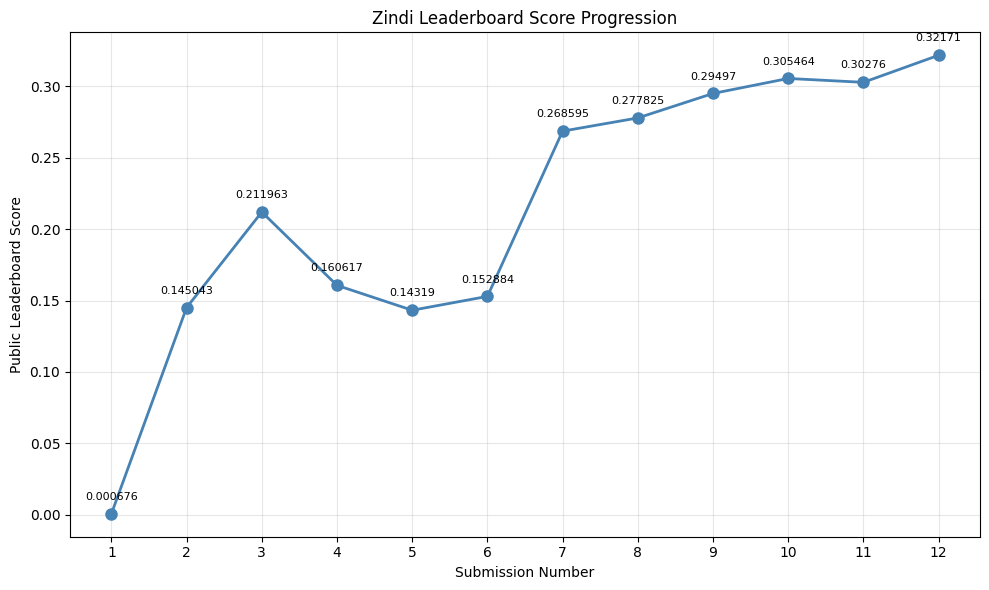

In [3]:
submissions = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
scores = [0.000676, 0.145043, 0.211963, 0.160617, 0.143190,
          0.152884, 0.268595, 0.277825, 0.294970, 0.305464, 0.302760, 0.32171]

plt.figure(figsize=(10, 6))
plt.plot(submissions, scores, marker='o', color='steelblue', linewidth=2, markersize=8)
plt.xlabel('Submission Number')
plt.ylabel('Public Leaderboard Score')
plt.title('Zindi Leaderboard Score Progression')
plt.xticks(submissions)
plt.grid(True, alpha=0.3)
for sub, score in zip(submissions, scores):
    plt.annotate(f'{score}', (sub, score), textcoords="offset points",
                xytext=(0, 10), ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('leaderboard_progression.png', dpi=150, bbox_inches='tight')
plt.show()